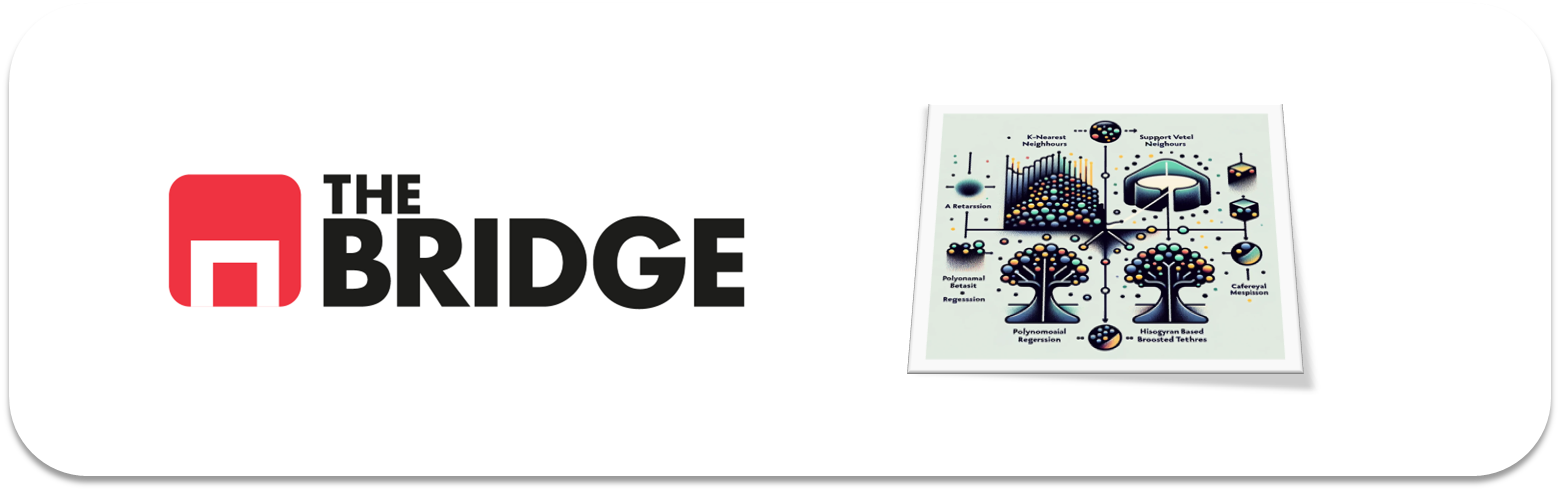

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import bootcampviztools as bt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier




### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df_credit = pd.read_csv("data/credit_npo.csv")

df = df_credit.copy()

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [5]:
df.isnull().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Machine Learning Supervisado de Clasificación Binaria.

Es un problema supervisado porque disponemos de una variable objetivo conocida (SeriousDlqin2yrs) a partir de la cual el modelo aprenderá patrones en los datos históricos para realizar predicciones sobre nuevos clientes.

Además, es una clasificación binaria porque la variable objetivo únicamente puede tomar dos valores:

0 → El cliente no tendrá dificultades financieras graves durante los próximos dos años.  
1 → El cliente tendrá dificultades financieras graves durante los próximos dos años.

In [6]:
target = "SeriousDlqin2yrs"

In [7]:
df["SeriousDlqin2yrs"].unique()

array([0, 1])

In [8]:
df["SeriousDlqin2yrs"].value_counts(normalize=True)*100

SeriousDlqin2yrs
0    93.108399
1     6.891601
Name: proportion, dtype: float64

Existe un fuerte desbalanceo de clases

La clase 0 representa aproximadamente el 93% de los casos,
mientras que la clase 1 representa únicamente el 7%.

Existe un fuerte desbalanceo de clases.
Por ello utilizaremos Recall como métrica principal
y aplicaremos técnicas de balanceado.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

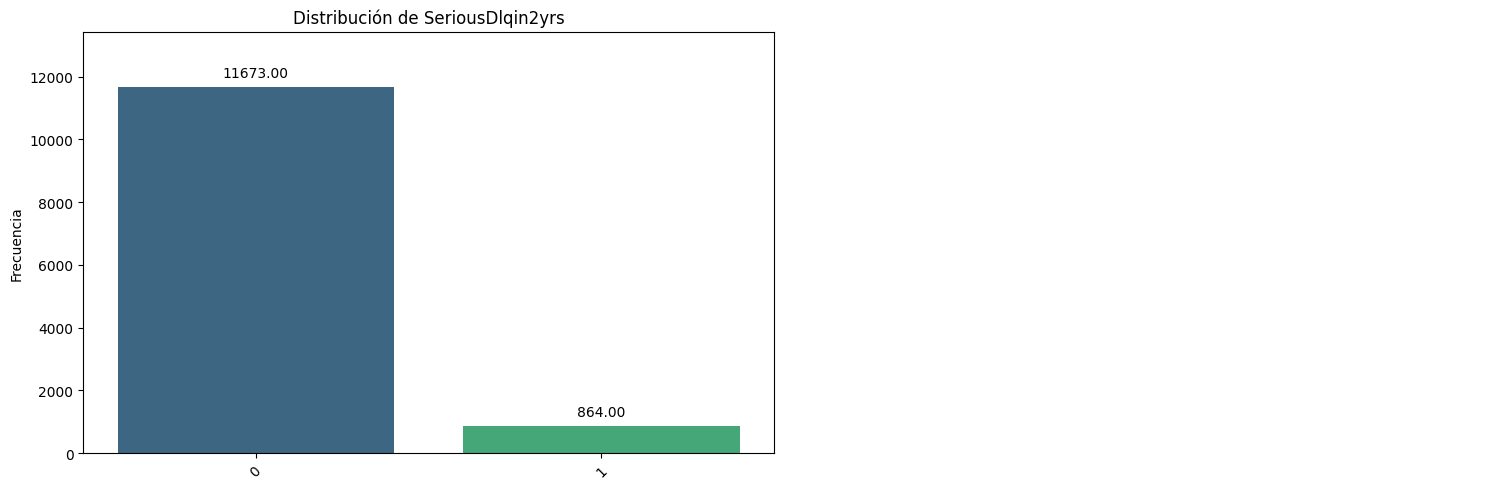

In [9]:
target = "SeriousDlqin2yrs"

bt.pinta_distribucion_categoricas(df,[target], mostrar_valores= True)

La variable target está fuertemente desbalanceada.   
La clase 0 representa aproximadamente el 93.1% de los casos,   
mientras que la clase 1 solo el 6.9%. Esto indica un problema   
de desbalance de clases, lo que puede afectar negativamente al   
entrenamiento de modelos de clasificación, ya que el modelo podría   
tender a predecir mayoritariamente la clase 0. En este caso sería   
recomendable aplicar técnicas de balanceo como oversampling,   
undersampling o el uso de métricas como F1-score en lugar de accuracy.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

Separación de variables

In [10]:
X = df.drop(columns=target)

y = df[target]


Train-Test Split

In [11]:
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42, stratify = df['SeriousDlqin2yrs'])

Tratamiento d enulos

In [12]:
X.isnull().sum()

RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

In [13]:
df["NumberOfDependents"].isnull().sum()

np.int64(177)

In [14]:
moda_train = train_set["NumberOfDependents"].mode()

In [15]:
moda_train = moda_train[0] # lo convierto en un valor (antes era un serie de pandas)

train_set["NumberOfDependents"] = train_set["NumberOfDependents"].fillna(moda_train)
test_set["NumberOfDependents"] = test_set["NumberOfDependents"].fillna(moda_train)

In [16]:
df["MonthlyIncome"].describe()

count     11816.000000
mean       6864.815420
std       11855.905437
min           0.000000
25%        3498.750000
50%        5416.000000
75%        8300.000000
max      702500.000000
Name: MonthlyIncome, dtype: float64

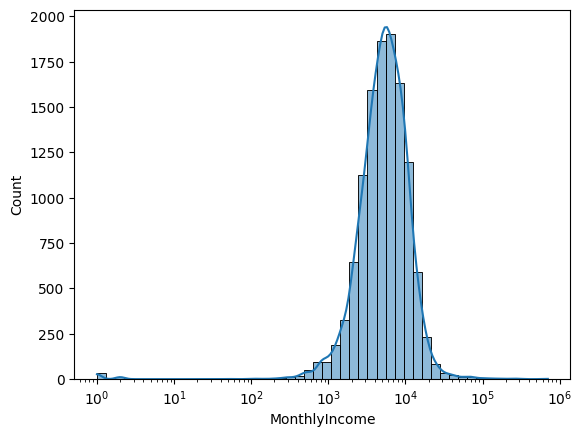

In [17]:
sns.histplot(df["MonthlyIncome"]+1, bins= 50, kde=True, log_scale=10)
plt.show()

In [18]:
mediana = train_set["MonthlyIncome"].quantile(0.5)

train_set["MonthlyIncome"] = train_set["MonthlyIncome"].fillna(mediana)
test_set["MonthlyIncome"] = test_set["MonthlyIncome"].fillna(mediana)

In [19]:
train_set.isna().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [20]:
test_set.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

X_train, y_train; X_test, y_test

In [21]:
X_train = train_set.drop("SeriousDlqin2yrs", axis=1)
y_train = train_set["SeriousDlqin2yrs"]

X_test = test_set.drop("SeriousDlqin2yrs", axis=1)
y_test = test_set["SeriousDlqin2yrs"]

Escalado (para KNN)

In [22]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)

**Función para evaluar modelos**

In [23]:
def evaluar_modelo(nombre, modelo, X_test, y_test, tecnica):

    pred = modelo.predict(X_test)

    return {
        "Modelo": nombre,
        "Tecnica": tecnica,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    }

**Los modelos: KNN, SVM Y RF**

In [24]:
resultados = []

knn = KNeighborsClassifier()
svm = SVC()
rf = RandomForestClassifier(random_state=42)

knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

resultados.append(
    evaluar_modelo("KNN", knn, X_test, y_test, "Original")
)

resultados.append(
    evaluar_modelo("SVM", svm, X_test, y_test, "Original")
)

resultados.append(
    evaluar_modelo("Random Forest", rf, X_test, y_test, "Original")
)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
pd.DataFrame(resultados)

,Modelo,Tecnica,Accuracy,Recall,Precision,F1
0,KNN,Original,0.929825,0.023121,0.363636,0.043478
1,SVM,Original,0.931021,0.000000,0.000000,0.000000
2,Random Forest,Original,0.933413,0.213873,0.544118,0.307054


**Oversampling (SMOTE)**

In [26]:
# SMOTE
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Modelos
knn_sm = KNeighborsClassifier()
svm_sm = SVC()
rf_sm = RandomForestClassifier(random_state=42)

# Entrenamiento
knn_sm.fit(X_train_sm, y_train_sm)
svm_sm.fit(X_train_sm, y_train_sm)
rf_sm.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
resultados.append(
    evaluar_modelo("KNN", knn_sm, X_test, y_test, "SMOTE")
)

resultados.append(
    evaluar_modelo("SVM", svm_sm, X_test, y_test, "SMOTE")
)

resultados.append(
    evaluar_modelo("Random Forest", rf_sm, X_test, y_test, "SMOTE")
)

In [28]:
###import imblearn

###print(imblearn.__version__)

**Undersampling**

In [29]:
# Crear undersampler
under = RandomUnderSampler(random_state=42)

# Generar dataset balanceado (SOLO TRAIN)
X_train_under, y_train_under = under.fit_resample(X_train, y_train)

# Crear modelos
knn_under = KNeighborsClassifier()
svm_under = SVC()
rf_under = RandomForestClassifier(random_state=42)

# Entrenar modelos
knn_under.fit(X_train_under, y_train_under)
svm_under.fit(X_train_under, y_train_under)
rf_under.fit(X_train_under, y_train_under)

# Evaluar y guardar resultados
resultados.append(
    evaluar_modelo("KNN", knn_under, X_test, y_test, "Undersampling")
)

resultados.append(
    evaluar_modelo("SVM", svm_under, X_test, y_test, "Undersampling")
)

resultados.append(
    evaluar_modelo("Random Forest", rf_under, X_test, y_test, "Undersampling")
)

**Hiperparámetros**

In [30]:
SVC(class_weight="balanced")

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

resultados con under y over

In [32]:
pd.DataFrame(resultados)

,Modelo,Tecnica,Accuracy,Recall,Precision,F1
0,KNN,Original,0.929825,0.023121,0.363636,0.043478
1,SVM,Original,0.931021,0.000000,0.000000,0.000000
2,Random Forest,Original,0.933413,0.213873,0.544118,0.307054
3,KNN,SMOTE,0.707337,0.393064,0.097561,0.156322
4,SVM,SMOTE,0.451754,0.670520,0.080893,0.144368
5,Random Forest,SMOTE,0.906300,0.404624,0.346535,0.373333
6,KNN,Undersampling,0.552233,0.566474,0.085515,0.148597
7,SVM,Undersampling,0.469697,0.653179,0.081706,0.145244
8,Random Forest,Undersampling,0.771132,0.739884,0.194825,0.308434


Comparación de modelos (recall)

In [33]:
df_resultados = pd.DataFrame(resultados)

In [36]:
type(df_resultados)

pandas.DataFrame

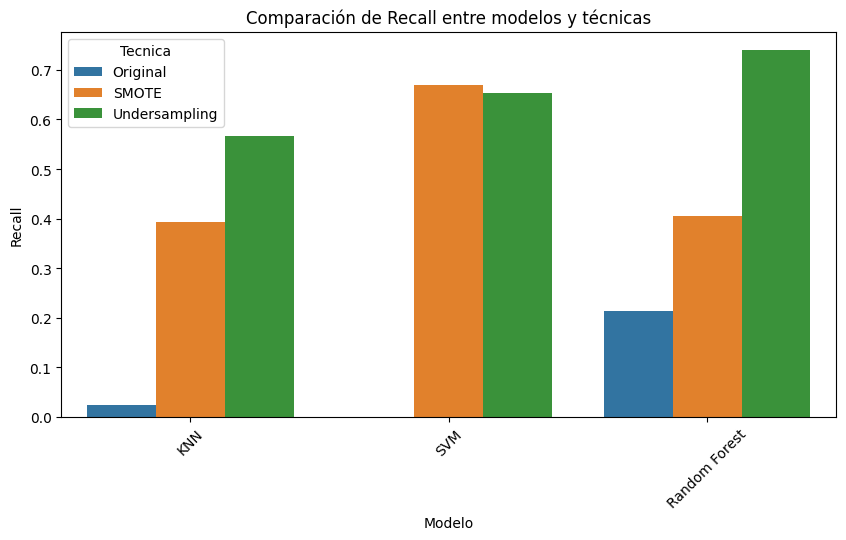

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_resultados,
    x="Modelo",
    y="Recall",
    hue="Tecnica"
)

plt.title("Comparación de Recall entre modelos y técnicas")
plt.xticks(rotation=45)
plt.show()

F-1 (equilibrio global)

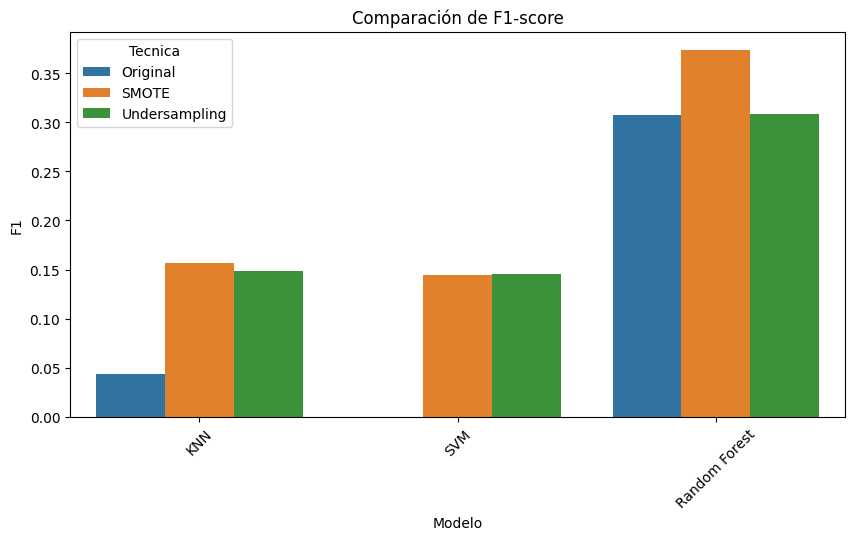

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_resultados,
    x="Modelo",
    y="F1",
    hue="Tecnica"
)

plt.title("Comparación de F1-score")
plt.xticks(rotation=45)
plt.show()

Precission

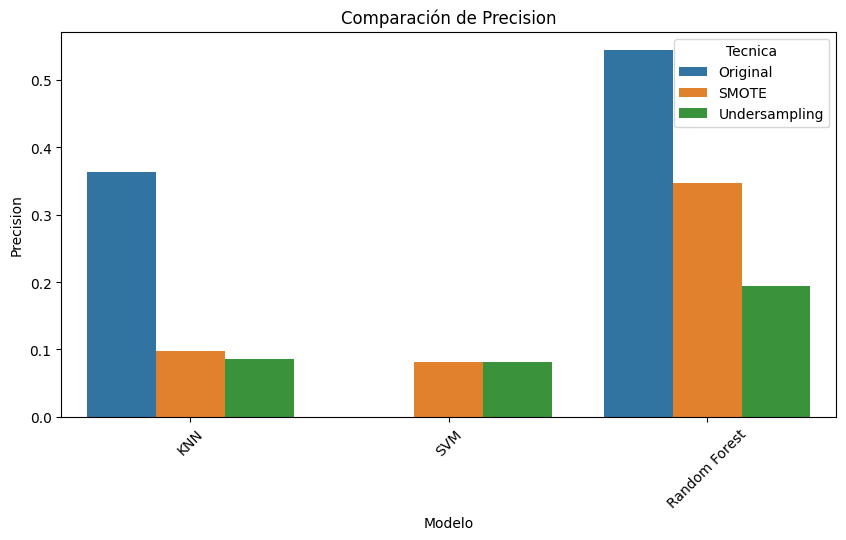

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_resultados,
    x="Modelo",
    y="Precision",
    hue="Tecnica"
)

plt.title("Comparación de Precision")
plt.xticks(rotation=45)
plt.show()

Heatman (con recall)

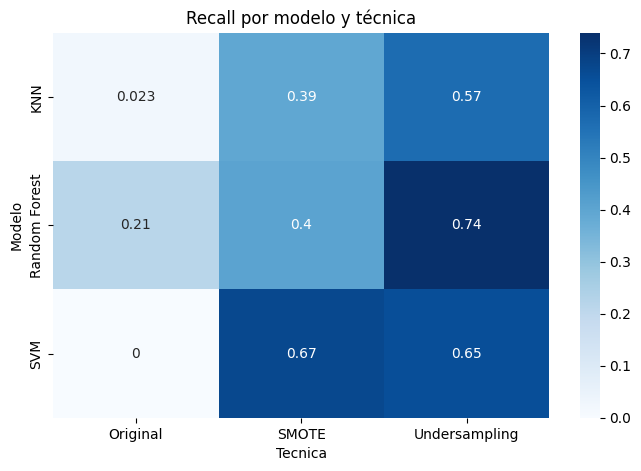

In [41]:
pivot = df_resultados.pivot_table(
    index="Modelo",
    columns="Tecnica",
    values="Recall"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("Recall por modelo y técnica")
plt.show()

In [42]:
df_resultados.loc[df_resultados["Recall"].idxmax()]

Modelo       Random Forest
Tecnica      Undersampling
Accuracy          0.771132
Recall            0.739884
Precision         0.194825
F1                0.308434
Name: 8, dtype: object

In [43]:
df_resultados.sort_values(by="Recall", ascending=False).head(3)

,Modelo,Tecnica,Accuracy,Recall,Precision,F1
8,Random Forest,Undersampling,0.771132,0.739884,0.194825,0.308434
4,SVM,SMOTE,0.451754,0.670520,0.080893,0.144368
7,SVM,Undersampling,0.469697,0.653179,0.081706,0.145244


#### SÚPER EXTRA

Con ROC-AUC para ver qué modelo separa mejor las clases

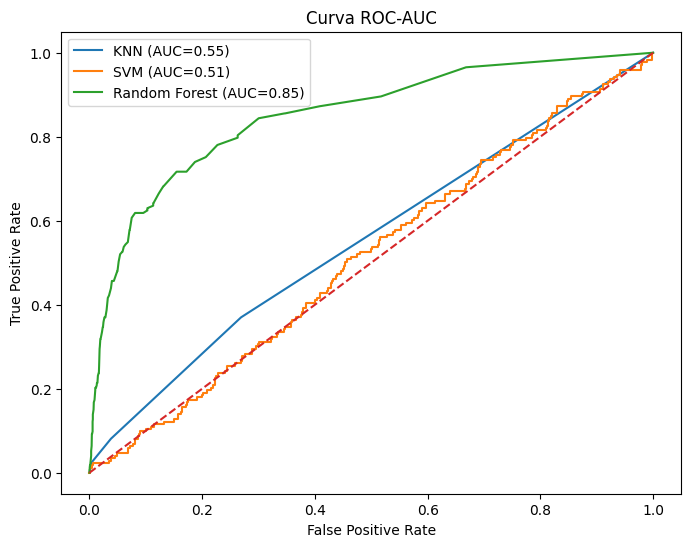

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Probabilidades (IMPORTANTE: no predict)
models = {
    "KNN": knn,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.title("Curva ROC-AUC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Curva Precisión-Recall

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.2f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

Ajuste de umbral de 0.5 a 0.3

In [47]:
y_proba_rf = rf.predict_proba(X_test)[:,1]

threshold = 0.3 

y_pred_thr = (y_proba_rf >= threshold).astype(int)

In [46]:
from sklearn.metrics import classification_report

print("Recall:", recall_score(y_test, y_pred_thr))
print("Precision:", precision_score(y_test, y_pred_thr))
print("F1:", f1_score(y_test, y_pred_thr))

print(classification_report(y_test, y_pred_thr))

Recall: 0.45664739884393063
Precision: 0.4388888888888889
F1: 0.4475920679886686
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2335
           1       0.44      0.46      0.45       173

    accuracy                           0.92      2508
   macro avg       0.70      0.71      0.70      2508
weighted avg       0.92      0.92      0.92      2508



El ajuste del umbral de decisión permite optimizar el  
equilibrio entre precisión y recall. Al reducir el umbral  
estándar de 0.5 a 0.3, el modelo aumenta su sensibilidad   
hacia la clase minoritaria, mejorando el recall a costa de   
una reducción en la precisión. Dado que el objetivo del problema   
es detectar clientes en riesgo, este trade-off es aceptable.